In [52]:
import pandas as pd
import joblib
import numpy as np
import sklearn 
import matplotlib.pyplot as plt


In [53]:
df = pd.read_csv("houseData.csv")

In [54]:
df.shape

(1000, 8)

In [55]:
df.isna().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [56]:
df.drop_duplicates(inplace=True)

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [58]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [59]:
df.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262382.852274
1,4272,3,3,2016,4.753014,1,6,985260.854490


In [60]:
x = df.drop(columns='House_Price')
y=df['House_Price']


In [61]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [62]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((800, 7), (200, 7), (800,), (200,))

In [63]:
from sklearn.preprocessing import MinMaxScaler
scaler =MinMaxScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

In [64]:
x_train_scale

array([[0.33919039, 0.25      , 1.        , ..., 0.28393465, 1.        ,
        0.11111111],
       [0.67081851, 1.        , 1.        , ..., 0.78115792, 0.        ,
        1.        ],
       [0.8905694 , 0.25      , 1.        , ..., 0.8062719 , 0.        ,
        0.66666667],
       ...,
       [0.21819395, 1.        , 0.        , ..., 0.16366323, 0.5       ,
        0.55555556],
       [0.30293594, 0.75      , 0.5       , ..., 0.8580875 , 0.        ,
        0.66666667],
       [0.19128114, 0.75      , 0.        , ..., 0.87030113, 0.5       ,
        0.        ]], shape=(800, 7))

In [65]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(x_train_scale,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
lr_pred = lr_model.predict(x_test_scale)

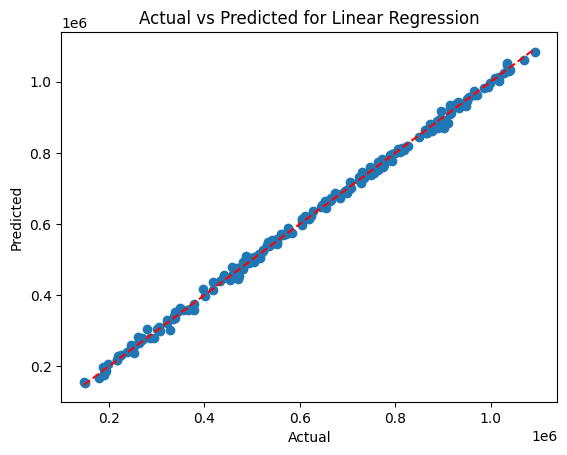

In [67]:
plt.scatter(y_test,lr_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted for Linear Regression')
plt.show()


In [68]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
R2_score = r2_score(y_test,lr_pred)
MAE = mean_absolute_error(y_test,lr_pred)
RMSE = np.sqrt(mean_squared_error(y_test,lr_pred))
print(f"R2 suqare : {R2_score}")
print(f"MAE : {MAE}")
print(f"RMSE : {RMSE}")

R2 suqare : 0.9984263636823413
MAE : 8174.583600006591
RMSE : 10071.484424137052


In [69]:
joblib.dump(lr_model, "linear_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("model saved successfully")

model saved successfully


In [70]:
df['Num_Bedrooms'].unique()

array([2, 3, 1, 5, 4])

In [71]:
df['Num_Bathrooms'].unique()

array([1, 3, 2])

In [72]:
df['Year_Built'].unique()

array([1981, 2016, 1977, 1993, 1990, 2012, 1972, 1997, 2006, 1982, 1973,
       1988, 1983, 2005, 1986, 1956, 2017, 2014, 1996, 1969, 1968, 1978,
       2009, 1967, 1984, 1992, 1960, 1998, 1987, 2013, 2018, 1957, 1980,
       1953, 1999, 1979, 2008, 1994, 1975, 1976, 1995, 2000, 1955, 1964,
       1991, 2022, 1966, 1971, 1962, 2002, 1952, 1970, 1950, 1954, 1985,
       2003, 1961, 2019, 2001, 2004, 2011, 2021, 2010, 1959, 2015, 2020,
       1974, 1958, 1963, 1965, 1989, 2007, 1951])

In [73]:
df['Garage_Size'].unique()

array([0, 1, 2])

In [74]:
y_test.tolist()

[901000.4882338208,
 494537.5115454976,
 949404.2006657254,
 1040389.0481357794,
 794010.0167336396,
 724033.5604571347,
 998439.2371139774,
 909713.435000704,
 792681.5184200833,
 947490.777477816,
 774150.0468123948,
 654466.9454086807,
 217462.4450570884,
 1034380.2041616676,
 530476.1232749791,
 194353.7361399757,
 441315.08847493527,
 354744.6305953098,
 755402.3726912518,
 348893.55395287194,
 763645.6101593996,
 475767.3504503976,
 676108.8512096877,
 887527.9071799915,
 438250.1761546225,
 402213.42189319455,
 472657.61431723344,
 453579.1055342158,
 191907.6525048871,
 489595.4124613424,
 270230.63769827964,
 893926.6294720689,
 771922.849821314,
 338350.5954344411,
 457643.0980423783,
 775773.2237663032,
 474659.86005527806,
 570399.7427677898,
 280961.6803897855,
 147601.55157708153,
 300656.0790681994,
 307101.6858385633,
 486872.0567091347,
 304653.63604893,
 1092026.89678641,
 1008539.156234348,
 747938.7115439639,
 818613.7108034128,
 1028282.3118218936,
 694917.30087454

In [75]:
lr_pred.tolist()

[868687.1074790407,
 490337.8982544699,
 945667.1242253822,
 1033402.8759924907,
 776698.7739058781,
 732444.0933530895,
 995051.9915627355,
 885174.7692436357,
 796730.5381713815,
 931741.0920927306,
 759486.7337677241,
 645409.4041020474,
 217706.20688727213,
 1047436.5266942865,
 536985.2837109955,
 187868.55343103508,
 456819.0234655625,
 357933.98497767333,
 743138.35721931,
 362670.94796790497,
 775101.0524852779,
 478174.42921701854,
 680966.0634507989,
 889457.5600147264,
 447158.9338722525,
 396997.78641330707,
 454334.2202696177,
 442837.53540885955,
 187336.81096627598,
 491668.1807041078,
 279715.8174097736,
 895941.0005743093,
 783583.1977884287,
 352212.9173796693,
 479313.28465599456,
 766612.6601435046,
 474636.25109507854,
 572446.3728803187,
 303449.7061964121,
 154599.27036071353,
 304341.0509212334,
 299677.0077528276,
 508575.91105887253,
 309977.51725284,
 1082131.7699476355,
 1011343.6357523286,
 760359.5646095864,
 807425.5744587743,
 1025548.1700941516,
 692212